# then correlation check, feature removal
## using log t1/2
2025-11-05, Alexander Minidis

2025-11-13 bayesian, XGBoost
### Air data, only MACCS descriptor

In [1]:
import sys
from pathlib import Path

notebookdir = Path.cwd().parents[2]
sys.path.append(str(notebookdir))  # this way we can import src modules even in different subfolders
from typing import Any
import pandas as pd
import numpy as np

import sqlalchemy as sa
from sqlalchemy.orm import sessionmaker
from src.db_utils import get_selected_data
from src.rdkit_tools import MACCS_NAMES
from src.ml_tools import decorrelate, drop_irrelevant_columns

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error, root_mean_squared_error
import xgboost as xgb

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 250)
%matplotlib inline

In [2]:
# set directories and filenames, load database
working_dir = Path.cwd().parent.parent
data_dir = working_dir / "processed_data"
database_file = data_dir / "hsbd_t_half_all.db"
engine = sa.create_engine(f"sqlite:///{database_file}")
Session = sessionmaker(bind=engine)

In [3]:
# get all data
air_data = get_selected_data("air", Session)
soil_data = get_selected_data("soil", Session)
water_data = get_selected_data("water", Session)
sediment_data = get_selected_data("sediment", Session)

air_data = drop_irrelevant_columns(air_data, to_drop={"rdkit"})
water_data = drop_irrelevant_columns(water_data, to_drop={"rdkit"})
soil_data = drop_irrelevant_columns(soil_data, to_drop={"rdkit"})
sediment_data = drop_irrelevant_columns(sediment_data, to_drop={"rdkit"})

target_column = "T_half_days"

## Preprocessing

In [4]:
# we will only use air data
X, y = air_data.drop(columns=[target_column]), air_data[target_column]
print(f"Number of features: {X.shape[1]}, number of samples: {X.shape[0]}")

Number of features: 166, number of samples: 309


### 1. Outlier detection

removed

### 2. Scaling/normalization

In [5]:
def correlated(X, threshold=0.95) -> list:
    """Decorrelate dataframe by finding which columns shall \
    be removed to achieve correlation level below threshold

    :param X: input dataframe
    :type X: pandas.core.frame.DataFrame
    :param threshold: maximum correlation allowed in the frame X
    :type threshold: float
    :return: list of columns to prune in order to achieve desired decorrelation level
    """

    # not superclean, but works here in n.b.
    if "target_column" in locals() or "target_column" in globals():
        if target_column in X.columns:
            X_ = X.drop(columns=[target_column])

    X_ = X.copy()
    N = X_.shape[1]
    corr = X_.corr().abs()

    to_drop = set()
    for i in range(N - 1):
        for j in range(i + 1, N):
            if corr.iloc[i, j] > threshold and i not in to_drop:
                to_drop.add(j)
    return [X_.columns[i] for i in to_drop]

In [6]:
# remove zero std columns (no variance)
zero_std_cols = X.columns[X.std() == 0]
X_scaled = X.drop(columns=zero_std_cols)
print(f"Number of features: {X_scaled.shape[1]}, number of samples: {X_scaled.shape[0]}")

Number of features: 136, number of samples: 309


In [7]:
# drop columns hihgly correlated to some others
cols_to_drop = correlated(X_scaled, threshold=0.95)
X_decorrelated = X_scaled.drop(columns=cols_to_drop)
print(f"Number of features: {X_decorrelated.shape[1]}, number of samples: {X_decorrelated.shape[0]}")

Number of features: 121, number of samples: 309


In [8]:
# # Ensure X_scaled and y are aligned and have no missing values
# mask_notnull = X_scaled.notnull().all(axis=1) & y.notnull()
# X_scaled = X_scaled[mask_notnull]
# y = y[mask_notnull]
# print(f"After scaling: X_scaled shape = {X_scaled.shape}, y shape = {y.shape}")

## Model

In [9]:
def output_metrics(y_true: Any, y_pred: Any) -> None:
    print(f"R2: {r2_score(y_true, y_pred):.3f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.3f}")
    print(f"MSE: {mean_squared_error(y_true, y_pred):.3f}")
    print(f"RMSE: {root_mean_squared_error(y_true, y_pred):.3f}")
    print(f"Explained Variance: {explained_variance_score(y_true, y_pred):.3f}")

In [10]:
X = X_decorrelated.copy()
y = np.log10(y)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Bayesian

In [12]:
# Bayesian Ridge Regression with GridSearchCV

param_grid = {
    "alpha_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "alpha_2": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_1": [1e-6, 1e-5, 1e-4, 1e-3],
    "lambda_2": [1e-6, 1e-5, 1e-4, 1e-3],
}

bayes_reg = BayesianRidge()
grid_search = GridSearchCV(bayes_reg, param_grid, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'alpha_1': 1e-06, 'alpha_2': 0.001, 'lambda_1': 1e-06, 'lambda_2': 0.001}


R2: 0.012
MAE: 18.111
MSE: 7884.271
RMSE: 88.793
Explained Variance: 0.019


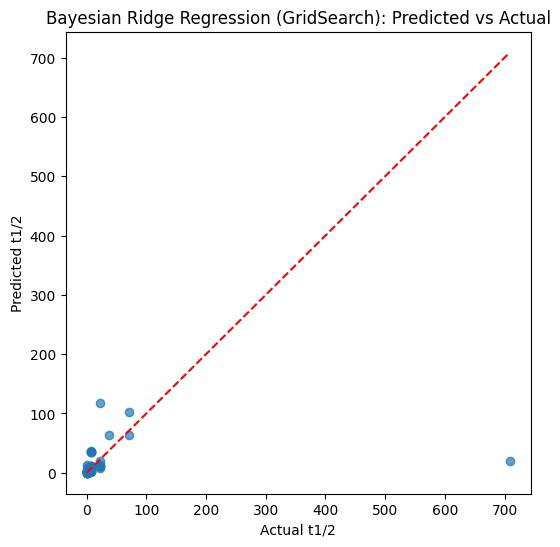

In [13]:
y_pred = grid_search.predict(X_test)

y_test_exp_bayes = np.power(10, y_test)
y_pred_exp_bayes = np.power(10, y_pred)
output_metrics(y_test_exp_bayes, y_pred_exp_bayes)

# Optional: plot predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test_exp_bayes, y_pred_exp_bayes, alpha=0.7)
plt.xlabel("Actual t1/2")
plt.ylabel("Predicted t1/2")
plt.title("Bayesian Ridge Regression (GridSearch): Predicted vs Actual")
plt.plot([y_test_exp_bayes.min(), y_test_exp_bayes.max()], [y_test_exp_bayes.min(), y_test_exp_bayes.max()], "r--")
plt.show()

Top 10 features (by absolute coefficient):
MACCS_099: 0.5460)
MACCS_103: 0.4305)
MACCS_152: 0.4233)
MACCS_151: 0.4029)
MACCS_164: 0.3892)
MACCS_113: 0.3737)
MACCS_062: 0.3721)
MACCS_158: 0.3458)
MACCS_106: 0.3448)
MACCS_118: 0.2989)


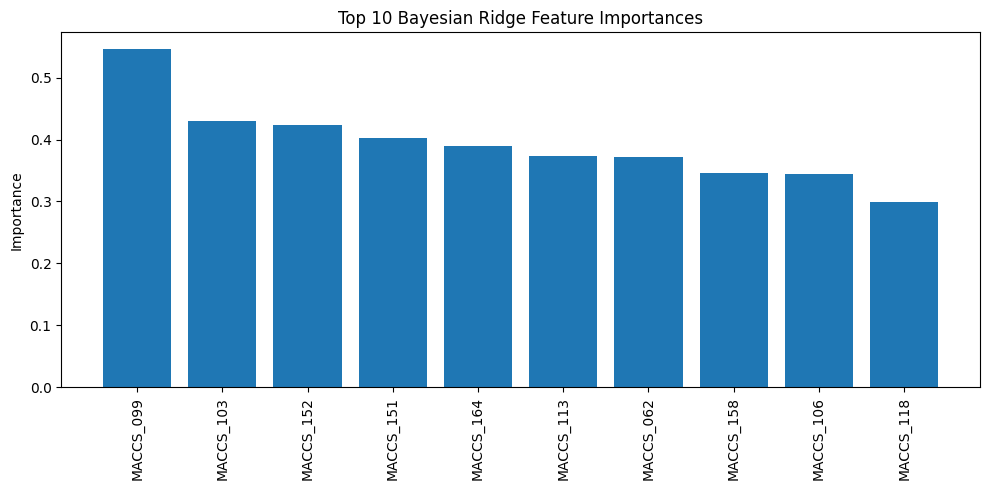

In [14]:
# Extract top 10 features by absolute coefficient value from Bayesian Ridge
importances_bayes = np.abs(grid_search.best_estimator_.coef_)
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx = np.argsort(importances_bayes)[-10:][::-1]
top_features = [(feature_names[i], importances_bayes[i]) for i in top_idx]
print("Top 10 features (by absolute coefficient):")
for name, val in top_features:
    print(f"{name}: {val:.4f})")

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_bayes[top_idx])
plt.xticks(range(10), X_train.columns[top_idx], rotation=90)
plt.title("Top 10 Bayesian Ridge Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

xgboost

In [15]:
# XGBOOST with GridSearchCV for hyperparameter tuning

xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
param_grid = {
    "n_estimators": [100, 300, 500, 1000],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.3],
    "subsample": [0.7, 0.9, 1.0],
    "colsample_bytree": [0.5, 0.7, 1.0],
}
# Use negative root mean squared error as scoring (available in sklearn 1.7.0)
grid_search_xgb = GridSearchCV(
    xgb_model, param_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose=2, error_score="raise"
)
grid_search_xgb.fit(X_train, y_train)
print("Best XGBoost parameters:", grid_search_xgb.best_params_)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best XGBoost parameters: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 8, 'n_estimators': 500, 'subsample': 1.0}


R2: -0.333
MAE: 24.891
MSE: 10637.766
RMSE: 103.140
Explained Variance: -0.333


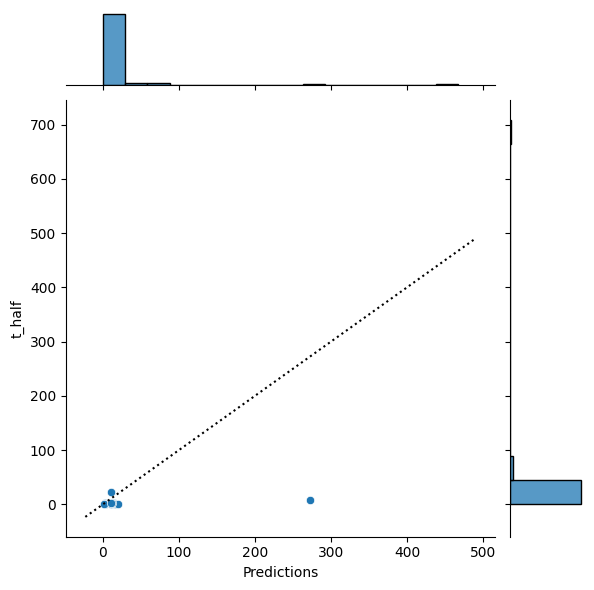

In [16]:
# Predict and evaluate XGBoost with best parameters from GridSearchCV
y_pred = grid_search_xgb.predict(X_test)
y_test_xgboost = np.power(10, y_test)
y_pred_xgboost = np.power(10, y_pred)
output_metrics(y_test_xgboost, y_pred_xgboost)
data = pd.concat([pd.Series(y_pred_xgboost), pd.Series(y_test_xgboost)], axis=1)
data.columns = ["Predictions", "t_half"]

g = sns.jointplot(x="Predictions", y="t_half", data=data)
x0, x1 = g.ax_joint.get_xlim()
y0, y1 = g.ax_joint.get_ylim()
lims = [max(x0, y0), min(x1, y1)]
g.ax_joint.plot(lims, lims, ":k")

Top 10 XGBoost features (by importance):
MACCS_103: 0.1827
MACCS_107: 0.0976
MACCS_164: 0.0281
MACCS_156: 0.0257
MACCS_158: 0.0253
MACCS_126: 0.0240
MACCS_161: 0.0219
MACCS_130: 0.0213
MACCS_151: 0.0197
MACCS_133: 0.0193


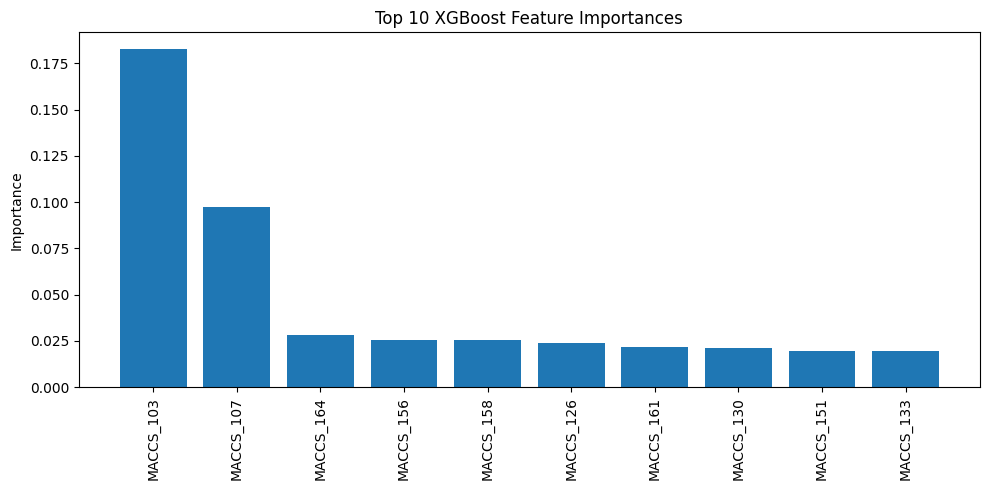

In [17]:
# Extract top 10 features by importance from XGBoost
importances_xgb = grid_search_xgb.best_estimator_.feature_importances_
feature_names = X_train.columns if hasattr(X_train, "columns") else [f"feat_{i}" for i in range(X_train.shape[1])]
top_idx_xgb = np.argsort(importances_xgb)[-10:][::-1]
top_features_xgb = [(feature_names[i], importances_xgb[i]) for i in top_idx_xgb]
print("Top 10 XGBoost features (by importance):")
for name, val in top_features_xgb:
    print(f"{name}: {val:.4f}")

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances_xgb[top_idx_xgb])
plt.xticks(range(10), [feature_names[i] for i in top_idx_xgb], rotation=90)
plt.title("Top 10 XGBoost Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()